# Problem 2.3 - Linear Regression as a Generative Model

Consider reformulating linear regression as a generative model, so we have $x = g[y,\phi'] = \phi'_0 + \phi'_1 y$.

1. What is the new loss function?

2. Find an expression for the inverse function $y = g^{-1}[x,\phi']$ that we would use to perform inference.

3. Will this model make the same predictions as the discriminative version for a given training dataset $\{x_i, y_i\}$? One way to establish this is to write code that fits a line to three data points using both methods and see if the result is the same.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# Function to help plot the data
def plot(x, y, phi0, phi1, phi2, phi3):
    fig,ax = plt.subplots()
    ax.scatter(x,y)
    plt.xlim([0,4])
    plt.ylim([0,7])
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    x_line = np.linspace(0, 4, 50)
    discriminative_y_line = phi0 + phi1 * x_line
    generative_y_line = (x_line - phi2) / phi3
    plt.plot(x_line, discriminative_y_line,'g-',lw=2, label="Discriminative model")
    plt.plot(x_line, generative_y_line,'r-',lw=2, label="Generative model")
    plt.legend()
    plt.show()

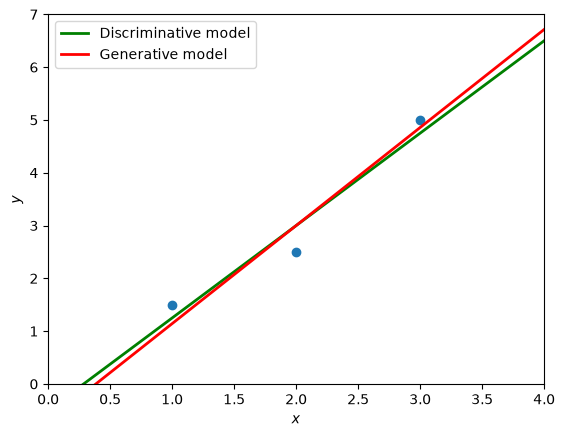

Discriminative model loss (vertical loss): 0.375
Generative model loss (horizontal loss): 0.11538461538461542


In [65]:
# Dataset
x = np.array([1, 2, 3])
y = np.array([1.5, 2.5, 5])

def compute_closed_form_solution(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    phi1 = np.sum((x - mean_x) * (y - mean_y)) / np.sum((x - mean_x) ** 2)
    phi0 = mean_y - phi1 * mean_x
    return phi0, phi1

phi0, phi1 = compute_closed_form_solution(x, y)
phi2, phi3 = compute_closed_form_solution(y, x)
plot(x, y, phi0, phi1, phi2, phi3)

def compute_loss(x, y, phi0, phi1):
    pred_y = phi0 + phi1 * x
    loss = np.sum((pred_y - y) ** 2)
    return loss

print("Discriminative model loss (vertical loss):", compute_loss(x, y, phi0, phi1))
print("Generative model loss (horizontal loss):", compute_loss(y, x, phi2, phi3))
